In [1]:

import os
import random
import warnings
import numpy as np
import pandas as pd
import joblib

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cpu


In [2]:

file_path = '../Data/FINAL_4CLASSES.csv'
df = pd.read_csv(file_path, encoding='utf-8', engine='python')

column_mapping = {
    'Gain(db)': 'Gain(dB)', 'Gain': 'Gain(dB)', 'gain': 'Gain(dB)',
    'Bandwidth': 'Bandwidth(Hz)', 'bandwidth': 'Bandwidth(Hz)',
    'GBW': 'GBW(MHz)', 'gbw': 'GBW(MHz)',
    'Power': 'Power(uW)', 'power': 'Power(uW)',
    'PM': 'PM(degree)', 'PhaseMargin': 'PM(degree)',
    'GM': 'GM(dB)', 'PSRR': 'PSRR(dB)',
    'SlewRate': 'SlewRate (V/us)', 'SlewRate(V/s)': 'SlewRate (V/us)',
    'CMRR': 'CMRR(dB)', 'class': 'Class', 'CLASS': 'Class'
}
df.rename(columns={k: v for k, v in column_mapping.items() if k in df.columns}, inplace=True)

df['Idc(uA)'] = 130.0
df['Length(um)'] = 0.18
df['CL(pF)'] = 10.0
df['CC(pF)'] = 55.0

FEATURE_COLUMNS = [
    'Temperature(°)', 'W12(um)', 'W34(um)', 'W58(um)', 'W6(um)', 'W7(um)',
    'Idc(uA)', 'Length(um)', 'CC(pF)', 'CL(pF)'
]
REGRESSION_TARGETS = [
    'Gain(dB)', 'Bandwidth(Hz)', 'GBW(MHz)', 'Power(uW)', 'PM(degree)',
    'GM(dB)', 'PSRR(dB)', 'SlewRate (V/us)', 'CMRR(dB)'
]

X_train_raw = df[FEATURE_COLUMNS]
y_train_raw = df[REGRESSION_TARGETS]

print("Dataset loaded. Temperature range in training:", df['Temperature(°)'].min(), "to", df['Temperature(°)'].max())


Dataset loaded. Temperature range in training: -40 to 125


In [3]:

# Load Scalers
label_encoder = joblib.load('label_encoder.pkl')
n_classes = len(label_encoder.classes_)
scaler_X = joblib.load('scaler_X.pkl')
scaler_y_reg = joblib.load('scaler_y_reg.pkl')

class PINN(nn.Module):
    def __init__(self, input_dim, hidden_dims, n_reg_outputs, n_classes, dropout_rate):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim
        self.backbone = nn.Sequential(*layers)
        self.regression_head = nn.Linear(prev_dim, n_reg_outputs)
        self.classification_head = nn.Linear(prev_dim, n_classes)

    def forward(self, x):
        shared = self.backbone(x)
        return self.regression_head(shared), self.classification_head(shared)

pinn = PINN(
    input_dim=len(FEATURE_COLUMNS),
    hidden_dims=[128, 128, 128, 128],
    n_reg_outputs=len(REGRESSION_TARGETS),
    n_classes=n_classes,
    dropout_rate=0.047,
).to(device)

pinn.load_state_dict(torch.load('pinn_model.pth', map_location=device))
pinn.eval()
print("PINN Loaded.")

# Train standard ML Baselines
X_scaled = scaler_X.transform(X_train_raw)
y_scaled = scaler_y_reg.transform(y_train_raw)

print("Training Random Forest...")
rf_model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_model.fit(X_scaled, y_scaled)
print("RF Trained.")

print("Training Standard MLP...")
mlp_model = MLPRegressor(hidden_layer_sizes=(128, 128, 128, 128), max_iter=200, random_state=42)
mlp_model.fit(X_scaled, y_scaled)
print("MLP Trained.")


PINN Loaded.
Training Random Forest...
RF Trained.
Training Standard MLP...
MLP Trained.


In [4]:

# 1. Pick a base sample
base_sample = X_train_raw.iloc[0].copy()

# 2. Define Out-Of-Distribution Temperatures
ood_high = [135, 150, 165]
ood_low = [-50, -60, -70]
interpolated = [-10, 15, 40, 85]

test_temps = ood_low + interpolated + ood_high

test_samples = []
for t in test_temps:
    s = base_sample.copy()
    s['Temperature(°)'] = t
    test_samples.append(s)

X_test_ood = pd.DataFrame(test_samples)
print("Generated Samples:")
display(X_test_ood[['Temperature(°)', 'W12(um)', 'W34(um)', 'Length(um)', 'Idc(uA)']])


Generated Samples:


,Temperature(°),W12(um),W34(um),Length(um),Idc(uA)
0,-50.0,8.0,30.0,0.18,130.0
0,-60.0,8.0,30.0,0.18,130.0
0,-70.0,8.0,30.0,0.18,130.0
0,-10.0,8.0,30.0,0.18,130.0
0,15.0,8.0,30.0,0.18,130.0
0,40.0,8.0,30.0,0.18,130.0
0,85.0,8.0,30.0,0.18,130.0
0,135.0,8.0,30.0,0.18,130.0
0,150.0,8.0,30.0,0.18,130.0
0,165.0,8.0,30.0,0.18,130.0


In [5]:

X_test_scaled = scaler_X.transform(X_test_ood)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

# PINN prediction
with torch.no_grad():
    y_pred_pinn_scaled, _ = pinn(X_test_tensor)
    y_pred_pinn = scaler_y_reg.inverse_transform(y_pred_pinn_scaled.cpu().numpy())

# RF prediction
y_pred_rf_scaled = rf_model.predict(X_test_scaled)
y_pred_rf = scaler_y_reg.inverse_transform(y_pred_rf_scaled)

# MLP prediction
y_pred_mlp_scaled = mlp_model.predict(X_test_scaled)
y_pred_mlp = scaler_y_reg.inverse_transform(y_pred_mlp_scaled)

idx_gain = REGRESSION_TARGETS.index('Gain(dB)')
idx_bw = REGRESSION_TARGETS.index('Bandwidth(Hz)')
idx_gbw = REGRESSION_TARGETS.index('GBW(MHz)')
idx_pm = REGRESSION_TARGETS.index('PM(degree)')

C1, C2, C3 = 11.28, 0.133, 1e-6

def calculate_violation(y_pred):
    p_gain = y_pred[:, idx_gain]
    p_bw = y_pred[:, idx_bw]
    p_gbw = y_pred[:, idx_gbw]
    p_pm = y_pred[:, idx_pm]
    
    gain_lin = 10 ** (p_gain / 20.0)
    pm_corr = (C1 - (C2 * p_pm))
    x_calc = gain_lin * p_bw * pm_corr * C3
    
    relative_violation = np.abs((p_gbw - x_calc) / (x_calc + 1e-8))
    return relative_violation * 100 # percentage

pinn_violations = calculate_violation(y_pred_pinn)
rf_violations = calculate_violation(y_pred_rf)
mlp_violations = calculate_violation(y_pred_mlp)

results = pd.DataFrame({
    'Temperature (C)': test_temps,
    'PINN Violation (%)': pinn_violations,
    'Random Forest Violation (%)': rf_violations,
    'Standard MLP Violation (%)': mlp_violations
})

def highlight_ood(val, temp):
    color = 'background-color: #ffe6e6' if temp < -40 or temp > 125 else ''
    return color

styled_results = results.style.apply(lambda x: [highlight_ood(v, x['Temperature (C)']) for v in x], axis=1).format({
    'PINN Violation (%)': '{:.2f}%',
    'Random Forest Violation (%)': '{:.2f}%',
    'Standard MLP Violation (%)': '{:.2f}%'
})

print("Performance Model Violations on Validation Samples:")
display(styled_results)


Performance Model Violations on Validation Samples:


,Temperature (C),PINN Violation (%),Random Forest Violation (%),Standard MLP Violation (%)
0,-50,2.59%,0.51%,2.16%
1,-60,3.12%,0.51%,2.83%
2,-70,3.40%,0.51%,3.33%
3,-10,4.72%,6.10%,3.81%
4,15,5.03%,9.84%,8.06%
5,40,3.56%,12.05%,10.95%
6,85,3.56%,13.69%,11.36%
7,135,47.23%,58.57%,77.39%
8,150,62.74%,58.57%,84.64%
9,165,68.85%,58.57%,88.59%


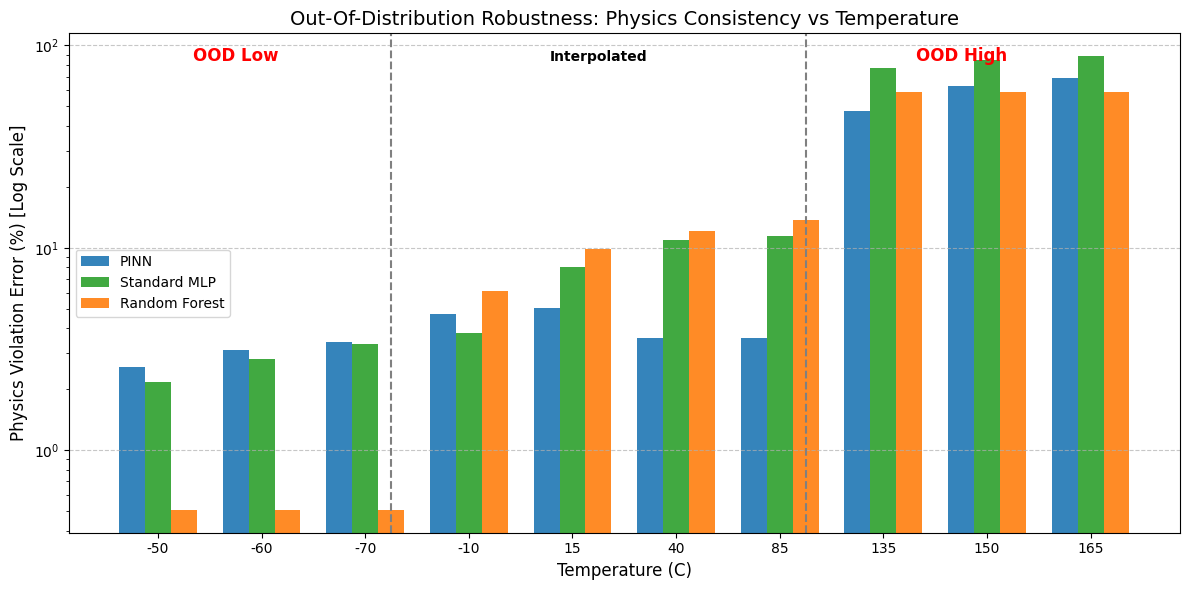

=== AVERAGE PHYSICS VIOLATION ON OUT-OF-DISTRIBUTION SAMPLES (<-40 or >125) ===
PINN:          31.32%
Standard MLP:  43.16%
Random Forest: 29.54%


In [6]:

plt.figure(figsize=(12, 6))
bar_width = 0.25
index = np.arange(len(test_temps))

plt.bar(index, results['PINN Violation (%)'], bar_width, label='PINN', color='#1f77b4', alpha=0.9)
plt.bar(index + bar_width, results['Standard MLP Violation (%)'], bar_width, label='Standard MLP', color='#2ca02c', alpha=0.9)
plt.bar(index + 2*bar_width, results['Random Forest Violation (%)'], bar_width, label='Random Forest', color='#ff7f0e', alpha=0.9)

plt.xlabel('Temperature (C)', fontsize=12)
plt.ylabel('Physics Violation Error (%)', fontsize=12)
plt.title('Out-Of-Distribution Robustness: Physics Consistency vs Temperature', fontsize=14)
plt.xticks(index + bar_width, results['Temperature (C)'])
plt.axvline(x=2.5, color='gray', linestyle='--')
plt.axvline(x=6.5, color='gray', linestyle='--')
plt.text(1, plt.ylim()[1]*0.9, 'OOD Low', ha='center', fontsize=12, fontweight='bold', color='red')
plt.text(4.5, plt.ylim()[1]*0.9, 'Interpolated', ha='center', fontsize=10, fontweight='bold')
plt.text(8, plt.ylim()[1]*0.9, 'OOD High', ha='center', fontsize=12, fontweight='bold', color='red')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yscale('log')
plt.ylabel('Physics Violation Error (%) [Log Scale]')
plt.tight_layout()
plt.show()

ood_high_mask = results['Temperature (C)'] > 125
ood_low_mask = results['Temperature (C)'] < -40
ood_mask = ood_high_mask | ood_low_mask

print("=== AVERAGE PHYSICS VIOLATION ON OUT-OF-DISTRIBUTION SAMPLES (<-40 or >125) ===")
print(f"PINN:          {results[ood_mask]['PINN Violation (%)'].mean():.2f}%")
print(f"Standard MLP:  {results[ood_mask]['Standard MLP Violation (%)'].mean():.2f}%")
print(f"Random Forest: {results[ood_mask]['Random Forest Violation (%)'].mean():.2f}%")


In [7]:
import pandas as pd
from IPython.display import display, HTML

# We'll create a master DataFrame joining the Inputs and the Outputs for all 3 models.
all_records = []

# Because inputs are identical per temperature, we reconstruct the records row by row
for i in range(len(X_test_ood)):
    base_input = X_test_ood.iloc[i].to_dict()
    
    # 1. PINN Record
    pinn_record = base_input.copy()
    pinn_record['Model'] = 'PINN'
    for j, col in enumerate(REGRESSION_TARGETS):
        pinn_record[col] = y_pred_pinn[i, j]
    pinn_record['Physics Violation (%)'] = pinn_violations[i]
    all_records.append(pinn_record)
    
    # 2. MLP Record
    mlp_record = base_input.copy()
    mlp_record['Model'] = 'Standard MLP'
    for j, col in enumerate(REGRESSION_TARGETS):
        mlp_record[col] = y_pred_mlp[i, j]
    mlp_record['Physics Violation (%)'] = mlp_violations[i]
    all_records.append(mlp_record)
    
    # 3. RF Record
    rf_record = base_input.copy()
    rf_record['Model'] = 'Random Forest'
    for j, col in enumerate(REGRESSION_TARGETS):
        rf_record[col] = y_pred_rf[i, j]
    rf_record['Physics Violation (%)'] = rf_violations[i]
    all_records.append(rf_record)

# Convert to DataFrame
df_all_outputs = pd.DataFrame(all_records)

# Reorder columns to put Model right next to Temperature
cols = df_all_outputs.columns.tolist()
t_col = df_all_outputs.filter(regex='(?i)temperature').columns[0]
cols.insert(cols.index(t_col) + 1, cols.pop(cols.index('Model')))
df_all_outputs = df_all_outputs[cols]

def highlight_pinn(s):
    if s['Model'] == 'PINN':
        return ['background-color: #e6f2ff'] * len(s)
    return [''] * len(s)

print("Comprehensive Input and Output Table Across All 3 Models:")
display_html = df_all_outputs.style.apply(highlight_pinn, axis=1).format({
    col: '{:.4f}' for col in REGRESSION_TARGETS + ['Physics Violation (%)']
})
display(display_html)

Comprehensive Input and Output Table Across All 3 Models:


,Temperature(°),Model,W12(um),W34(um),W58(um),W6(um),W7(um),Idc(uA),Length(um),CC(pF),CL(pF),Gain(dB),Bandwidth(Hz),GBW(MHz),Power(uW),PM(degree),GM(dB),PSRR(dB),SlewRate (V/us),CMRR(dB),Physics Violation (%)
0,-50.000000,PINN,8.000000,30.000000,18.000000,30.000000,30.000000,130.000000,0.180000,55.000000,10.000000,52.4971,25678.0703,30.9457,2155.0518,63.8594,8.2374,48.6216,6.8360,60.4492,2.5863
1,-50.000000,Standard MLP,8.000000,30.000000,18.000000,30.000000,30.000000,130.000000,0.180000,55.000000,10.000000,52.2559,26253.0745,30.9259,2170.6466,63.6662,8.1934,48.7368,6.9747,60.2759,2.1576
2,-50.000000,Random Forest,8.000000,30.000000,18.000000,30.000000,30.000000,130.000000,0.180000,55.000000,10.000000,52.2662,25126.0000,28.5279,2145.8570,64.1203,8.3655,48.9416,6.8029,60.2920,0.5051
3,-60.000000,PINN,8.000000,30.000000,18.000000,30.000000,30.000000,130.000000,0.180000,55.000000,10.000000,52.5948,26522.2441,33.1884,2178.8430,63.4112,8.1289,48.9028,6.9550,60.5147,3.1222
4,-60.000000,Standard MLP,8.000000,30.000000,18.000000,30.000000,30.000000,130.000000,0.180000,55.000000,10.000000,52.3616,27056.1828,33.3750,2202.1644,63.0791,8.0255,49.0511,7.1367,60.2747,2.8267
5,-60.000000,Random Forest,8.000000,30.000000,18.000000,30.000000,30.000000,130.000000,0.180000,55.000000,10.000000,52.2662,25126.0000,28.5279,2145.8570,64.1203,8.3655,48.9416,6.8029,60.2920,0.5051
6,-70.000000,PINN,8.000000,30.000000,18.000000,30.000000,30.000000,130.000000,0.180000,55.000000,10.000000,52.6938,27278.1777,35.2736,2198.8083,63.0067,8.0267,49.1439,7.0643,60.5768,3.4015
7,-70.000000,Standard MLP,8.000000,30.000000,18.000000,30.000000,30.000000,130.000000,0.180000,55.000000,10.000000,52.4796,27772.9363,35.8335,2233.3797,62.4958,7.8601,49.3552,7.2963,60.2752,3.3270
8,-70.000000,Random Forest,8.000000,30.000000,18.000000,30.000000,30.000000,130.000000,0.180000,55.000000,10.000000,52.2662,25126.0000,28.5279,2145.8570,64.1203,8.3655,48.9416,6.8029,60.2920,0.5051
9,-10.000000,PINN,8.000000,30.000000,18.000000,30.000000,30.000000,130.000000,0.180000,55.000000,10.000000,52.0210,22226.5605,24.3258,2085.9946,65.1206,8.5907,47.3620,6.4149,60.1494,4.7167
